# Mathematical exercises

**Exercise 1** (3 points): Problem 6.6 in the PRML textbook.


## Ornstein-Uhlenbeck process

An Ornstein-Uhlenbeck stochastic process can be simulated in discrete time as an autoregressive "AR(1)" model, described by the equation
$$
y(t) = (1-a)y(t-1) + b \xi(t),
$$
where $0 < a < 1$, $b > 0$, and $\xi(t) \sim \mathcal{N}(0,1)$ is drawn independently at each time step. This equation can describe, for example, the time-dependent position of a particle that gets kicked around by random forces (the second term on the right hand side) and has a restoring force toward $y=0$ (the first term on the right hand side). This model and related ones have widespread applications in the physical sciences, engineering, and financial modeling.

**Exercise 2** (3 points): Use the above equation to show that the autocorrelations are given by, for $\tau \geq 0$, $C(\tau) \equiv E[y(t) y(t-\tau)] = (1-a)^\tau C(0)$ and, for general $\tau$, $C(\tau) = (1-a)^{|\tau|} C(0)$. 

# Coding exercises

In the exercises below, we will further explore the Ornstein-Uhlenbeck process, showing that it can be understood as an example of a Gaussian process.

Reminder: Once your notebook is complete, you should restart the kernel, run all of the cells in order, and make sure that no errors occur. Notebooks that run successfully without errors will be awarded one extra credit point.

In [32]:
import numpy as np
import matplotlib.pyplot as plt

**Exercise 1** (5 points): Simulate an AR(1) process using the above equation for 10,000 time steps with $y(0) = 0$, $b=1$, and choosing your own value for $a$. Plot the first 100 timesteps of $y(t)$. Compute the autocorrelation $C(\tau)$ for $-100 < \tau < 100$ empirically (i.e. replacing the expectation described above by an average over $t$), and plot the empirical $C(\tau)/C(0)$ together with the theoretically derived result from above.

In [42]:
range(1,100)

range(1, 100)

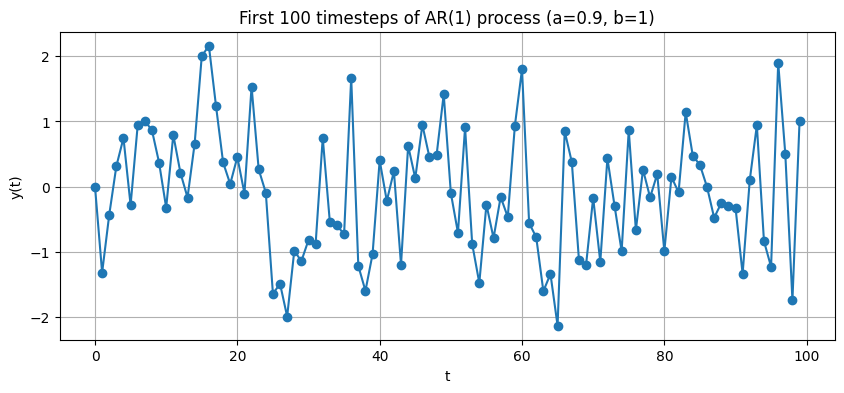

In [87]:
## Solution ##
n_steps = 10000
b = 1
a = .9 # (0 < a < 1)
y = np.zeros(n_steps)

# Simulate AR(1) process
gen = np.random.default_rng()
for t in range(1, n_steps):
    y[t] = (1 - a) * y[t - 1] + b * gen.normal()

plt.figure(figsize=(10, 4))
plt.plot(np.arange(100), y[:100], marker='o', linestyle='-')
plt.title(f'First 100 timesteps of AR(1) process (a={a}, b={b})')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.show()

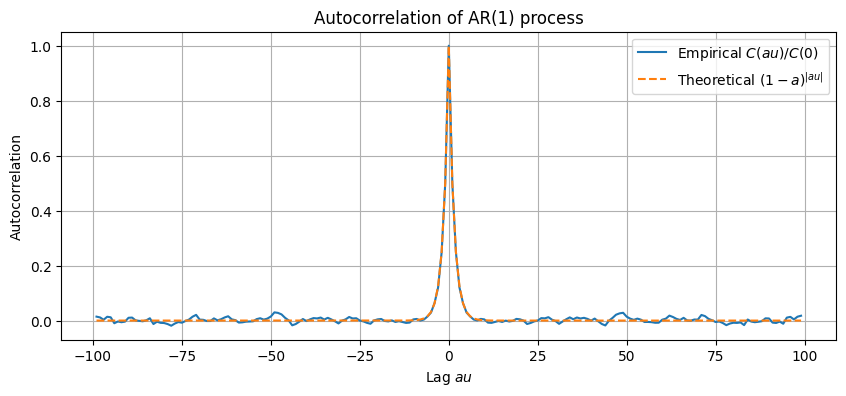

In [34]:
# Empirical autocorrelation
max_lag = 99
lags = np.arange(-max_lag, max_lag + 1)
C_tau = np.array([np.mean(y[max_lag:-max_lag] * y[max_lag + lag:n_steps - max_lag + lag]) for lag in lags])
C0 = np.mean(y[max_lag:-max_lag] ** 2)
empirical_autocorr = C_tau / C0

# Theoretical autocorrelation
th_autocorr = (1 - a) ** np.abs(lags)

plt.figure(figsize=(10, 4))
plt.plot(lags, empirical_autocorr, label='Empirical $C(\tau)/C(0)$')
plt.plot(lags, th_autocorr, '--', label='Theoretical $(1-a)^{|\tau|}$')
plt.title('Autocorrelation of AR(1) process')
plt.xlabel('Lag $\tau$')
plt.ylabel('Autocorrelation')
plt.legend()
plt.grid(True)
plt.show()

Rather than generating an OU process by simulating it online (i.e. one time step at a time), we can interpret it as a Gaussian process. This means that, if we have $N$ timesteps, then a curve such as the one plotted in the previous exercise is interpreted as a single sample from a $N$-dimensional multivariate Gaussian distribution: $\vec{y} \sim \mathcal{N}(\vec{y} | 0, \mathbf{K})$, where the kernel matrix has entries $K_{tt'} = \exp(-\theta|t-t'|)$, and $\vec{y} = [y(1), y(2), \ldots, y(N)]^\top$.

**Exercise 2** (5 points): Using the Gaussian process approach, generate and plot several examples of an OU process. Use the value of $\theta$ that gives the same autocorrelations as the previous exercise, and state what this value is. Finally, compute and plot the autocorrelation curve as in the previous exercise, verifying that it again matches the theoretically derived result.

theta is 0.6931471805599453


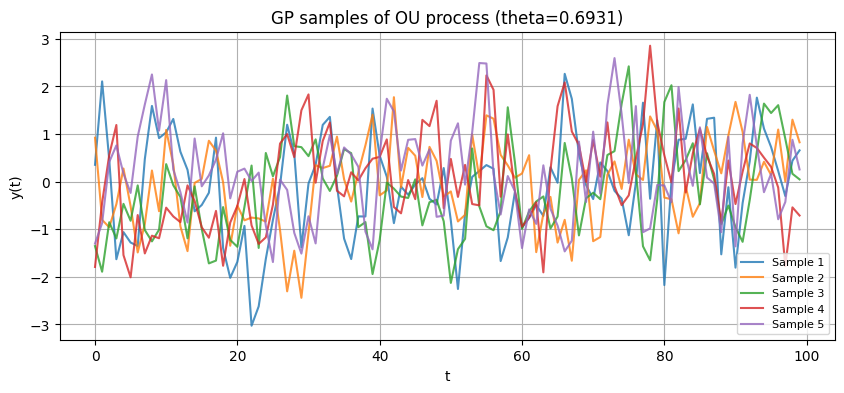

In [35]:
## Solution ##
# exp(-theta*|tau|) = (1-a)^|tau|
theta = -np.log(1 - a)
print(f"theta is {theta}")

N = 100  

# kernel matrix K[i,j] = exp(-theta * |i - j|)
K = [[np.exp(-theta * abs(i - j)) for j in range(N)] for i in range(N)]
K = np.array(K)

# Draw several GP samples directly from the multivariate Gaussian
mean = np.zeros(N)
n_samples = 5
samples = np.random.multivariate_normal(mean, K, size=n_samples)

plt.figure(figsize=(10, 4))
for i in range(n_samples):
    plt.plot(samples[i], alpha=0.8, label=f'Sample {i+1}')
plt.title(f'GP samples of OU process (theta={theta:.4f})')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

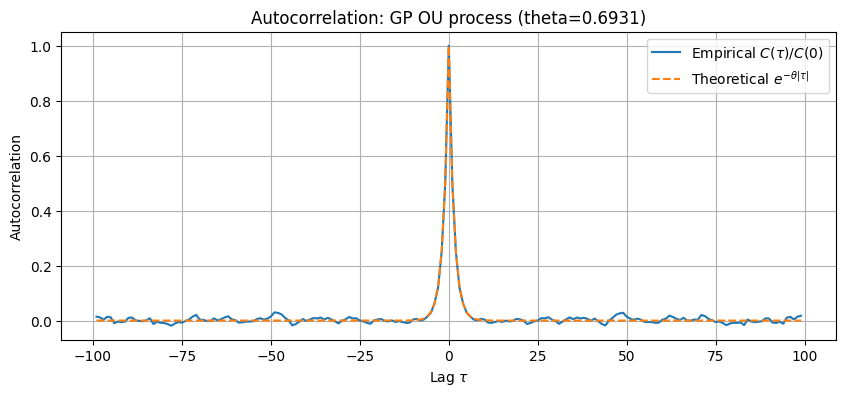

In [36]:
# Empirical autocorrelation (reusing y from Exercise 1)
max_lag = 99
lags = list(range(-max_lag, max_lag + 1))
C_tau_gp = []
for lag in lags:
    total = 0.0
    count = 0
    for t in range(max_lag, n_steps - max_lag):
        total += y[t] * y[t + lag]
        count += 1
    C_tau_gp.append(total / count)

C0_gp = C_tau_gp[max_lag]  # lag=0 entry
empirical_autocorr_gp = [c / C0_gp for c in C_tau_gp]

# Theoretical: exp(-theta * |tau|)
th_autocorr_gp = [np.exp(-theta * abs(lag)) for lag in lags]

# Plot
plt.figure(figsize=(10, 4))
plt.plot(lags, empirical_autocorr_gp, label='Empirical $C(\\tau)/C(0)$')
plt.plot(lags, th_autocorr_gp, '--', label='Theoretical $e^{-\\theta|\\tau|}$')
plt.title(f'Autocorrelation: GP OU process (theta={theta:.4f})')
plt.xlabel('Lag $\\tau$')
plt.ylabel('Autocorrelation')
plt.legend()
plt.grid(True)
plt.show()


**Exercise 3** (5 points): Up to this point, we have considered 1-dimensional inputs $t$ (time). However, the kernel definition $k(\mathbf{x}, \mathbf{x}')$ applies generally to vectors $\mathbf{x} \in \mathbb{R}^D$. A classic application of Gaussian Processes in $D=2$ is geostatistics, where the technique is often referred to as "Kriging."

As usual, responsible AI use is encouraged in this last exercise, e.g. using AI as a tutor explaining the theory and helping debug implementations. Optionally, you may include a brief reflection on how you used AI and what you learned from the interaction.

1.  **Data Generation:** Use an AI assistant (like ChatGPT, Claude, or Gemini) to generate a Python dictionary containing the Latitude, Longitude, and approximate average January Temperature (in Celsius) for 15-20 discrete major US cities.
2.  **The Model:** Use `sklearn.gaussian_process.GaussianProcessRegressor` to fit a model to this data. The inputs $\mathbf{x}$ are the (Latitude, Longitude) coordinates, and the targets $t$ are the temperatures.
3.  **The Kernel:** Construct a Kernel that combines an `RBF` (Radial Basis Function) kernel with a `WhiteKernel` (to handle noise).
    *   *Hint:* Weather patterns often stretch differently East-West (due to jet streams) than North-South. Prompt your AI assistant to explain "Anisotropic kernels" and how to set the `length_scale` parameter in `sklearn` to be a vector rather than a scalar to account for this.
4.  **Visualization:** Create a grid of points covering the continental United States. Use your fitted GP to predict the mean temperature and the standard deviation (uncertainty) at every point on this grid. Plot these as two heatmaps (contour plots).
    *   Observe how the uncertainty $\sigma(\mathbf{x})$ behaves: it should be low near the cities you provided and high in large empty spaces (like the Great Plains), demonstrating the "local" nature of the RBF kernel.


In [37]:
## Solution ##

# Part 1: City data — (Latitude, Longitude, avg January temperature in Celsius)
city_data = {
    "New York":       {"lat": 40.71, "lon": -74.01, "temp_jan": -0.6},
    "Los Angeles":    {"lat": 34.05, "lon": -118.24, "temp_jan": 13.9},
    "Chicago":        {"lat": 41.88, "lon": -87.63, "temp_jan": -5.6},
    "Houston":        {"lat": 29.76, "lon": -95.37, "temp_jan": 11.1},
    "Phoenix":        {"lat": 33.45, "lon": -112.07, "temp_jan": 12.8},
    "Philadelphia":   {"lat": 39.95, "lon": -75.17, "temp_jan": 0.6},
    "San Antonio":    {"lat": 29.42, "lon": -98.49, "temp_jan": 10.6},
    "San Diego":      {"lat": 32.72, "lon": -117.16, "temp_jan": 13.3},
    "Dallas":         {"lat": 32.78, "lon": -96.81, "temp_jan": 6.7},
    "Seattle":        {"lat": 47.61, "lon": -122.33, "temp_jan": 4.4},
    "Denver":         {"lat": 39.74, "lon": -104.98, "temp_jan": -0.3},
    "Boston":         {"lat": 42.36, "lon": -71.06, "temp_jan": -1.7},
    "Miami":          {"lat": 25.77, "lon": -80.19, "temp_jan": 19.9},
    "Atlanta":        {"lat": 33.75, "lon": -84.39, "temp_jan": 5.6},
    "Minneapolis":    {"lat": 44.98, "lon": -93.27, "temp_jan": -11.1},
    "New Orleans":    {"lat": 29.95, "lon": -90.07, "temp_jan": 11.7},
    "Portland":       {"lat": 45.52, "lon": -122.68, "temp_jan": 4.1},
    "Las Vegas":      {"lat": 36.17, "lon": -115.14, "temp_jan": 7.2},
}

# Extract arrays for modeling
import numpy as np
coords = np.array([[d["lat"], d["lon"]] for d in city_data.values()])
temps  = np.array([d["temp_jan"] for d in city_data.values()])
cities = list(city_data.keys())

print(f"{'City':<16} {'Lat':>6} {'Lon':>8} {'Jan Temp (C)':>13}")
print("-" * 46)
for name, d in city_data.items():
    print(f"{name:<16} {d['lat']:>6.2f} {d['lon']:>8.2f} {d['temp_jan']:>13.1f}")


City                Lat      Lon  Jan Temp (C)
----------------------------------------------
New York          40.71   -74.01          -0.6
Los Angeles       34.05  -118.24          13.9
Chicago           41.88   -87.63          -5.6
Houston           29.76   -95.37          11.1
Phoenix           33.45  -112.07          12.8
Philadelphia      39.95   -75.17           0.6
San Antonio       29.42   -98.49          10.6
San Diego         32.72  -117.16          13.3
Dallas            32.78   -96.81           6.7
Seattle           47.61  -122.33           4.4
Denver            39.74  -104.98          -0.3
Boston            42.36   -71.06          -1.7
Miami             25.77   -80.19          19.9
Atlanta           33.75   -84.39           5.6
Minneapolis       44.98   -93.27         -11.1
New Orleans       29.95   -90.07          11.7
Portland          45.52  -122.68           4.1
Las Vegas         36.17  -115.14           7.2


In [41]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

kernel = RBF(length_scale=[5.0, 15.0], length_scale_bounds=[(1, 50), (1, 100)]) \
       + WhiteKernel(noise_level=1.0)

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)
gp.fit(coords, temps)

print(" kernel:", gp.kernel_)


 kernel: RBF(length_scale=[12.2, 22.7]) + WhiteKernel(noise_level=0.0292)


In [39]:
lat_min, lat_max = 24.0, 50.0
lon_min, lon_max = -125.0, -66.0
n_grid = 100

lat_grid = np.linspace(lat_min, lat_max, n_grid)
lon_grid = np.linspace(lon_min, lon_max, n_grid)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
grid_points = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])

mean_pred, std_pred = gp.predict(grid_points, return_std=True)
mean_map = mean_pred.reshape(n_grid, n_grid)
std_map  = std_pred.reshape(n_grid, n_grid)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:444: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:444: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:444: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_


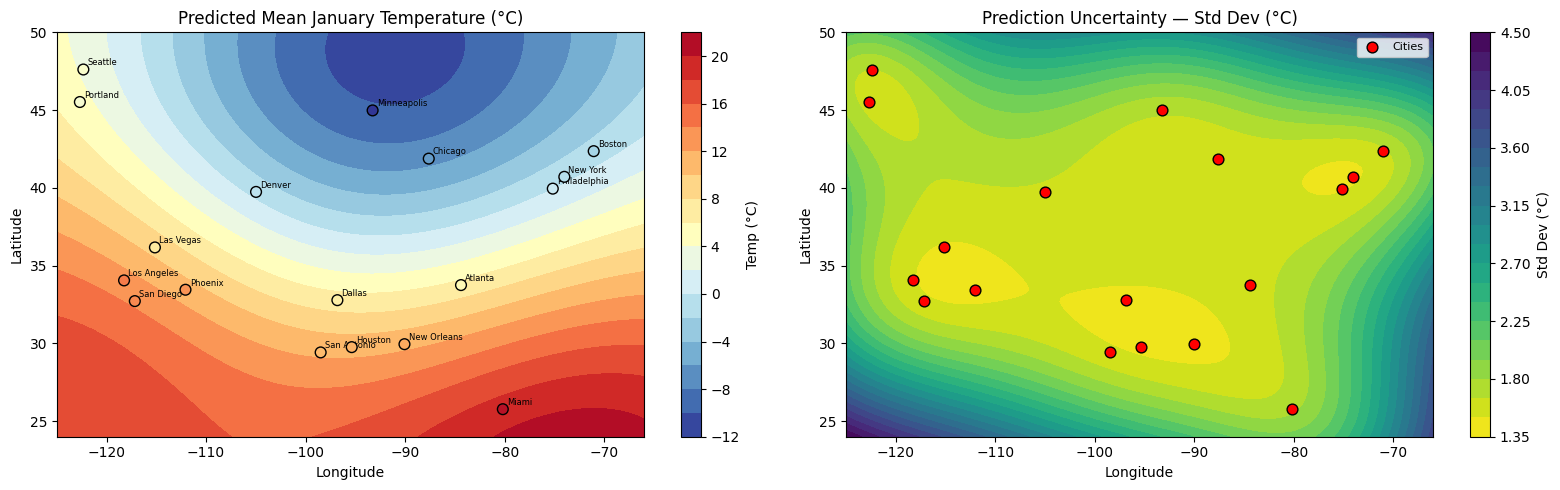

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Mean temperature heatmap ---
cf1 = axes[0].contourf(lon_mesh, lat_mesh, mean_map, levels=20, cmap='RdYlBu_r')
plt.colorbar(cf1, ax=axes[0], label='Temp (°C)')
axes[0].scatter(coords[:, 1], coords[:, 0], c=temps, cmap='RdYlBu_r',
                edgecolors='k', s=60, zorder=5, vmin=mean_map.min(), vmax=mean_map.max())
for i, name in enumerate(cities):
    axes[0].annotate(name, (coords[i, 1], coords[i, 0]), fontsize=6,
                     textcoords="offset points", xytext=(3, 3))
axes[0].set_title('Predicted Mean January Temperature (°C)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# --- Uncertainty (std dev) heatmap ---
cf2 = axes[1].contourf(lon_mesh, lat_mesh, std_map, levels=20, cmap='viridis_r')
plt.colorbar(cf2, ax=axes[1], label='Std Dev (°C)')
axes[1].scatter(coords[:, 1], coords[:, 0], color='red', edgecolors='k',
                s=60, zorder=5, label='Cities')
axes[1].set_title('Prediction Uncertainty — Std Dev (°C)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
